### Pipeline to train model with XgBoost without removal of outlier
- Testing:
```
Accuracy: 0.9997325648489721
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    967950
           1       1.00      1.00      1.00    265994
```
- Validation (After balancing the dataset)
```
Accuracy: 0.9376940382452194
              precision    recall  f1-score   support

           0       0.89      1.00      0.94    444500
           1       1.00      0.88      0.93    444500
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load the datasets

In [15]:
df_1 = pd.read_csv("../Dataset/S2_chest_data.csv")
print("loaded df_1")
df_2 = pd.read_csv("../Dataset/S3_chest_data.csv")
print("loaded df_2")
df_3 = pd.read_csv("../Dataset/S9_chest_data.csv")
print("loaded df_3")

loaded df_1
loaded df_2
loaded df_3


In [16]:
df = pd.concat([df_1, df_2, df_3], ignore_index=True)

### Drop duplicates

In [17]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label
count,1.245642e+07,1.245642e+07,1.245642e+07,1.245642e+07,1.245642e+07,1.245642e+07,1.245642e+07,1.245642e+07,1.245642e+07
mean,8.105350e-01,-5.314409e-02,-2.189315e-01,1.163399e-03,-2.907157e-03,4.058731e+00,3.258237e+01,5.752931e-02,1.299293e+00
std,1.360911e-01,9.121925e-02,3.631794e-01,2.352152e-01,2.477390e-02,2.813162e+00,1.736223e+00,3.785641e+00,1.644564e+00
min,-6.600000e+00,-6.600000e+00,-6.600000e+00,-1.500000e+00,-1.500000e+00,0.000000e+00,-2.731500e+02,-5.000000e+01,0.000000e+00
25%,7.950000e-01,-1.118000e-01,-4.390000e-01,-9.896851e-02,-1.062012e-02,1.506805e+00,3.139291e+01,-1.864624e+00,0.000000e+00
50%,8.600000e-01,-4.500002e-02,-2.294000e-01,-1.496887e-02,-2.243042e-03,3.074646e+00,3.267508e+01,-2.059937e-01,1.000000e+00
75%,8.990000e-01,-1.600027e-03,1.139998e-02,4.815674e-02,5.081177e-03,7.089615e+00,3.420688e+01,2.003479e+00,2.000000e+00
max,2.981400e+00,1.322400e+00,4.508200e+00,1.499954e+00,1.464340e+00,1.636543e+01,3.523074e+01,3.297272e+01,7.000000e+00


### Data filtering

In [18]:
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

### Categorization

In [19]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["Label"] = df["Label"].apply(apply_target)

### handle -ve EMG

In [20]:
df["EMG"] = df["EMG"].abs()

### Handling the -Ve temp value

In [21]:
df = df[df["Temp"] > 0]

### Train test split

In [22]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

### Balance out the train dataset only

In [23]:
from sklearn.utils import resample

# majority class
low_stress = train[train["Label"] == 0]

# minority class
high_stress = train[train["Label"] == 1]

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

train = pd.concat([low_downsampled, high_stress]).sample(frac=1)

train['Label'].value_counts()

Label
1    1063923
0    1063923
Name: count, dtype: int64

### Train the model

In [24]:
x_train = train.drop("Label", axis=1)
y_train = train["Label"]

y_test = test["Label"]
x_test = test.drop("Label", axis=1)

In [12]:
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test :", np.unique(y_test))
print("Value counts:\n", pd.Series(y_train).value_counts())

Unique labels in y_train: [0 1]
Unique labels in y_test : [0 1]
Value counts:
 Label
0    1063923
1    1063923
Name: count, dtype: int64


In [13]:
pd.DataFrame(x_train).describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp
count,2.127846e+06,2.127846e+06,2.127846e+06,2.127846e+06,2.127846e+06,2.127846e+06,2.127846e+06,2.127846e+06
mean,8.134036e-01,-4.241690e-02,-3.340762e-01,1.213548e-03,1.113101e-02,4.095323e+00,3.260784e+01,5.667597e-02
std,1.252927e-01,7.898695e-02,2.623868e-01,2.285004e-01,1.380356e-02,2.812503e+00,1.789761e+00,3.487381e+00
min,3.116000e-01,-4.194000e-01,-1.050200e+00,-1.499405e+00,0.000000e+00,4.196167e-01,2.804526e+01,-2.017212e+01
25%,8.026000e-01,-1.044000e-01,-4.790000e-01,-8.839417e-02,3.250122e-03,1.669693e+00,3.132962e+01,-1.913452e+00
50%,8.634000e-01,-3.420001e-02,-3.144000e-01,-1.446533e-02,7.369995e-03,3.104019e+00,3.246747e+01,-2.700806e-01
75%,8.961999e-01,2.599955e-03,-1.606000e-01,4.829407e-02,1.414490e-02,7.085800e+00,3.441782e+01,1.899719e+00
max,1.358600e+00,5.125999e-01,1.036200e+00,1.499588e+00,1.047180e+00,1.209869e+01,3.514563e+01,1.954193e+01


In [25]:
from xgboost import XGBClassifier, plot_importance, plot_tree

model = XGBClassifier(
    n_estimators      = 100,       # number of boosting rounds
    max_depth         = 3,         # depth of each tree
    learning_rate     = 0.2,       # shrinks contribution of each tree (eta)
    subsample         = 0.7,       # fraction of samples per tree
    colsample_bytree  = 0.7,       # fraction of features per tree
    gamma             = 0,         # min loss reduction to split a node
    reg_alpha         = 0,         # L1 regularization
    reg_lambda        = 1,         # L2 regularization
    eval_metric       = "logloss",  # "logloss" for binary
    objective        = "binary:logistic",  # ← add this for binary (0/1)
    random_state      = 42,
    n_jobs            = -1
)



model.fit(
    x_train, y_train,
    eval_set              = [(x_train, y_train), (x_test, y_test)],
    verbose               = 10        # print every 10 rounds
)

[0]	validation_0-logloss:0.62719	validation_1-logloss:0.62884
[10]	validation_0-logloss:0.26799	validation_1-logloss:0.27417
[20]	validation_0-logloss:0.14051	validation_1-logloss:0.14301
[30]	validation_0-logloss:0.06694	validation_1-logloss:0.06766
[40]	validation_0-logloss:0.03969	validation_1-logloss:0.04001
[50]	validation_0-logloss:0.02639	validation_1-logloss:0.02659
[60]	validation_0-logloss:0.01585	validation_1-logloss:0.01600
[70]	validation_0-logloss:0.00903	validation_1-logloss:0.00914
[80]	validation_0-logloss:0.00569	validation_1-logloss:0.00576
[90]	validation_0-logloss:0.00419	validation_1-logloss:0.00425
[99]	validation_0-logloss:0.00297	validation_1-logloss:0.00303


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### Test the model with test dataset

In [26]:
X_test = test.drop("Label", axis=1)

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score, classification_report
y_test = test["Label"]
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9997147358389036
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    967950
           1       1.00      1.00      1.00    265994

    accuracy                           1.00   1233944
   macro avg       1.00      1.00      1.00   1233944
weighted avg       1.00      1.00      1.00   1233944



### Test model on other Dataset

In [29]:
validate_df =  pd.read_csv("../Dataset/S4_chest_data.csv")

In [30]:
# filtering the dataset
accept_label = [1, 2, 3, 4]
validate_df = validate_df[validate_df["Label"].isin(accept_label)]

# categorization
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

validate_df["Label"] = validate_df["Label"].apply(apply_target)

# handling -ve EMG value
validate_df["EMG"] = validate_df["EMG"].abs()


In [31]:
from sklearn.utils import resample

# majority class
low_stress = validate_df[validate_df["Label"] == 0]

# minority class
high_stress = validate_df[validate_df["Label"] == 1]

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

validate_df = pd.concat([low_downsampled, high_stress]).sample(frac=1)

validate_df['Label'].value_counts()

Label
1    444500
0    444500
Name: count, dtype: int64

In [32]:
X_Validate = validate_df.drop("Label", axis=1)   
y_validate = validate_df["Label"]

In [33]:
y_pred = model.predict(X_Validate)


print("Accuracy:", accuracy_score(y_validate, y_pred))
print(classification_report(y_validate, y_pred))

Accuracy: 0.9390494938132733
              precision    recall  f1-score   support

           0       0.89      1.00      0.94    444500
           1       0.99      0.88      0.94    444500

    accuracy                           0.94    889000
   macro avg       0.94      0.94      0.94    889000
weighted avg       0.94      0.94      0.94    889000



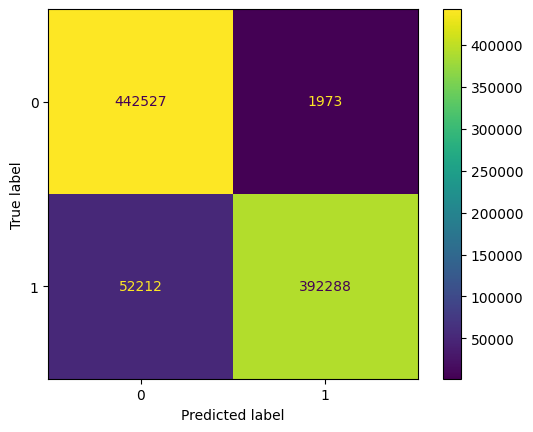

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_validate, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [35]:
missed = X_Validate[(y_validate == 1) & (y_pred == 0)]
missed.describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp
count,52212.000000,52212.000000,52212.000000,52212.000000,52212.000000,52212.000000,52212.000000,52212.000000
mean,0.904922,-0.090424,-0.159809,0.000794,0.013245,2.846869,33.249581,0.048608
std,0.015308,0.022911,0.022989,0.258435,0.011236,0.326677,0.082375,1.513106
min,0.739200,-0.192200,-0.372000,-0.872452,0.000000,2.138901,33.057434,-6.654358
25%,0.897800,-0.103400,-0.174200,-0.089859,0.004898,2.537918,33.176270,-0.990295
50%,0.905000,-0.091200,-0.159400,-0.023758,0.010529,2.928162,33.233490,-0.025940
75%,0.912000,-0.078600,-0.144800,0.028805,0.018494,3.078842,33.320892,0.993347
max,1.059400,0.060000,-0.042200,1.499496,0.120438,4.995346,33.726166,6.500244


In [36]:
correct = X_Validate[(y_validate == 1) & (y_pred == 1)]
correct.describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp
count,392288.000000,392288.000000,392288.000000,392288.000000,392288.000000,392288.000000,392288.000000,392288.000000
mean,0.902598,-0.092647,-0.169904,0.001208,0.011382,4.259431,33.646460,0.050124
std,0.013979,0.023620,0.039073,0.259188,0.009799,0.536738,0.066226,2.471484
min,0.784600,-0.259800,-0.389800,-0.626038,0.000000,2.894974,33.378235,-8.854675
25%,0.895200,-0.107400,-0.194400,-0.080612,0.004166,3.749084,33.620117,-1.353455
50%,0.902600,-0.093800,-0.167200,-0.023712,0.008972,4.521179,33.654938,-0.032043
75%,0.909800,-0.079000,-0.143000,0.016525,0.015884,4.702759,33.698883,1.289368
max,1.066200,0.109600,0.106400,1.499954,0.133347,5.183029,33.935730,11.456299


EDA
```
Missed (FN):   mean ≈ 2.86
Correct (TP):  mean ≈ 4.26
```
EMG
```
Missed:   ≈ 0.013
Correct:  ≈ 0.011
```

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

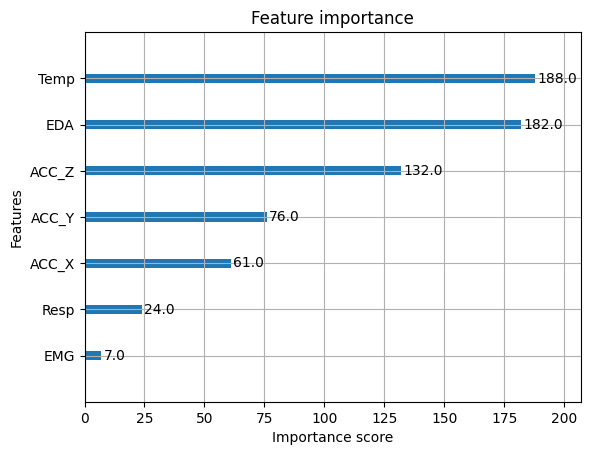

In [45]:
from xgboost import plot_importance
plot_importance(model)

### LIME

In [38]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=x_train.values,
    feature_names=train.drop("Label", axis=1).columns,
    mode="classification",
    discretize_continuous=False
)

In [39]:
input_data = pd.DataFrame([{
    "ACC_X": 1.2,
    "ACC_Y": -0.5,
    "ACC_Z":-1.0,
    "ECG": 0.5,
    "EMG": 0.1,
    "EDA": 9.2,
    "Temp": 29.30,
    "Resp": -0.40
}])



explanation = explainer.explain_instance(
    data_row=input_data.iloc[0].values,   # <-- FIX
    predict_fn=model.predict_proba,
    num_features=8
)

explanation.as_list()

[('ACC_Z', 0.022230048686498194),
 ('Temp', 0.015789496666381027),
 ('ACC_Y', 0.010183196648356183),
 ('EMG', -0.009208487396605973),
 ('EDA', -0.007789758746459372),
 ('ECG', -0.006745791287295905),
 ('Resp', 0.004483779682068556),
 ('ACC_X', -0.0019574566926688626)]

In [40]:
model.classes_

array([0, 1])

In [41]:
model.predict_proba(input_data)

array([[9.9922025e-01, 7.7977282e-04]], dtype=float32)

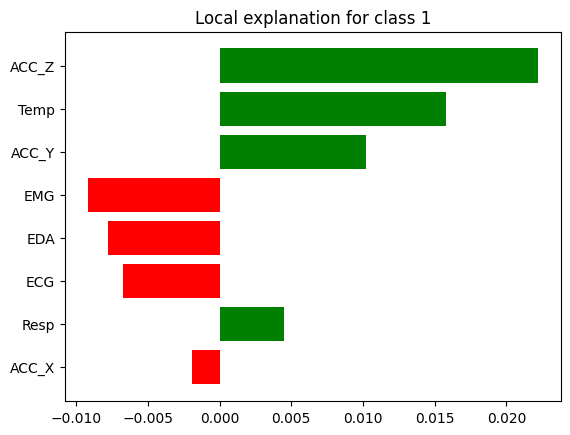

In [42]:
import matplotlib.pyplot as plt

fig = explanation.as_pyplot_figure()
plt.show()

### SHAP

In [43]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer(x_test)

c:\Users\Yadnesh\OneDrive\Desktop\codes\XAI_For_Stress_and_Mental_Health_Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


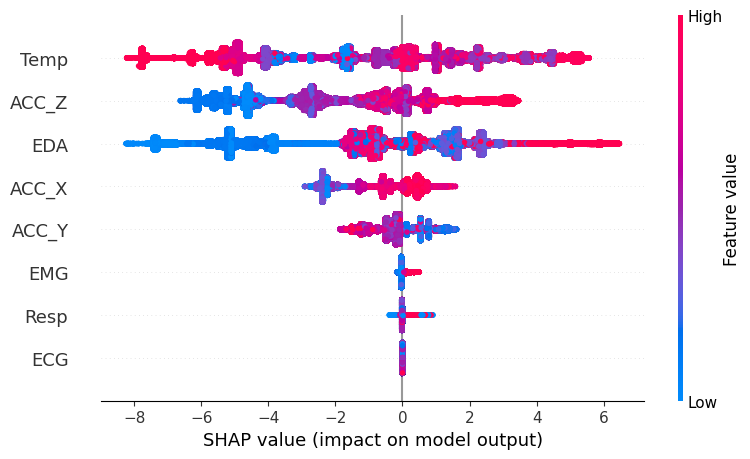

In [44]:
shap.summary_plot(shap_values, x_test)